In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import os
import cv2
from glob import glob
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# GPU Configuration for T4
import tensorflow as tf

# Check for GPU availability
print("GPU Available: ", tf.test.is_gpu_available())
print("GPU Device Name: ", tf.test.gpu_device_name())

# Set memory growth to avoid OOM errors
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU configured: {gpus}")
    except RuntimeError as e:
        print(e)

# Verify TensorFlow can see the GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found')
else:
    print('Found GPU at: {}'.format(device_name))

GPU Available:  True
GPU Device Name:  /device:GPU:0
GPU configured: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found GPU at: /device:GPU:0


In [4]:
# 1. Imports and basic setup
import os
import json
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
# (If you did not use roc_curve/auc in DenseNet, you can drop them.)

mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow version:", tf.__version__)
print("Mixed precision policy:", mixed_precision.global_policy())
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
Mixed precision policy: <DTypePolicy "mixed_float16">
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 3. Directories (same structure as before)
ROOT_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"
EUROSAT_DIR = os.path.join(ROOT_DIR, "eurosat")
MODELS_DIR = os.path.join(EUROSAT_DIR, "models")
LOGS_DIR = os.path.join(EUROSAT_DIR, "logs")
FIGS_DIR = os.path.join(EUROSAT_DIR, "figs")
METRICS_DIR = os.path.join(EUROSAT_DIR, "metrics")

for d in [ROOT_DIR, EUROSAT_DIR, MODELS_DIR, LOGS_DIR, FIGS_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)
    print("Ensured directory:", d)

Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/logs
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/figs
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/metrics


In [7]:
# 4. Load EuroSAT (RGB) via TFDS
DATASET_NAME = "eurosat/rgb"

# TFDS defines only a 'train' split; do custom train/val/test split
(ds_full,), ds_info = tfds.load(
    DATASET_NAME,
    split=["train"],
    with_info=True,
    as_supervised=True
)

num_classes = ds_info.features["label"].num_classes
class_names = ds_info.features["label"].names
print("Classes:", num_classes, class_names)

num_examples = ds_info.splits["train"].num_examples
train_size = int(0.6 * num_examples)
val_size = int(0.2 * num_examples)
test_size = num_examples - train_size - val_size

print("Total:", num_examples)
print("Train/Val/Test:", train_size, val_size, test_size)

ds_train = ds_full.take(train_size)
ds_temp = ds_full.skip(train_size)
ds_val = ds_temp.take(val_size)
ds_test = ds_temp.skip(val_size)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/eurosat/rgb/incomplete.7QW1CS_2.0.0/eurosat-train.tfrecord*...:   0%|     …

Dataset eurosat downloaded and prepared to /root/tensorflow_datasets/eurosat/rgb/2.0.0. Subsequent calls will reuse this data.
Classes: 10 ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total: 27000
Train/Val/Test: 16200 5400 5400


In [8]:
# 5. Preprocessing & augmentation (identical to other EuroSAT notebooks)
IMG_SIZE = 128
BATCH_SIZE = 64
AUTO = tf.data.AUTOTUNE

def preprocess(image, label, training=False):
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
    return image, label

def prepare_ds(ds, training=False):
    if training:
        ds = ds.shuffle(1000, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: preprocess(x, y, training=training),
                num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTO)
    return ds

train_ds = prepare_ds(ds_train, training=True)
val_ds = prepare_ds(ds_val, training=False)
test_ds = prepare_ds(ds_test, training=False)

In [9]:
# 6. Apply MobileNetV2 preprocessing
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

def add_mobilenet_preprocess(ds):
    def _f(images, labels):
        images = mobilenet_preprocess(images * 255.0)
        return images, labels
    return ds.map(_f, num_parallel_calls=AUTO)

train_ds = add_mobilenet_preprocess(train_ds)
val_ds = add_mobilenet_preprocess(val_ds)
test_ds = add_mobilenet_preprocess(test_ds)

In [10]:
# 7. Ensure class mapping file exists (same pattern as DenseNet)
class_mapping_path = os.path.join(METRICS_DIR, "eurosat_class_mapping.json")
if not os.path.exists(class_mapping_path):
    with open(class_mapping_path, "w") as f:
        json.dump({"class_names": class_names}, f, indent=2)
    print("Saved class mapping to:", class_mapping_path)
else:
    print("Class mapping already exists:", class_mapping_path)

Class mapping already exists: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/metrics/eurosat_class_mapping.json


In [11]:
# 8. Build MobileNetV2 backbone + head
base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

base_model.trainable = False  # same strategy

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_layer_mobilenet")
x = base_model(inputs, training=False)
x = layers.Dense(256, activation="relu", name="dense")(x)
x = layers.Dropout(0.3, name="dropout")(x)
outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="dense_1")(x)

model = keras.Model(inputs, outputs, name="mobilenetv2_eurosat")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_eurosat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_mobilenet           │ (None, 128, 128, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# 9. Compile model (same hyperparameters for fair comparison)
initial_lr = 1e-3
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# 10. Callbacks for MobileNetV2
csv_log_path = os.path.join(LOGS_DIR, "eurosat_mobilenetv2_history.csv")
checkpoint_path = os.path.join(MODELS_DIR, "eurosat_mobilenetv2_best.weights.h5")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.CSVLogger(csv_log_path),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Training complete. History logged to:", csv_log_path)

Epoch 1/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7973 - loss: 0.6116
Epoch 1: val_accuracy improved from -inf to 0.91444, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_mobilenetv2_best.weights.h5
254/254 ━━━━━━━━━━━━━━━━━━━━ 111s 299ms/step - accuracy: 0.7975 - loss: 0.6107 - val_accuracy: 0.9144 - val_loss: 0.2547 - learning_rate: 0.0010
Epoch 2/20
250/254 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9109 - loss: 0.2644
Epoch 2: val_accuracy improved from 0.91444 to 0.92926, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_mobilenetv2_best.weights.h5
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9110 - loss: 0.2640 - val_accuracy: 0.9293 - val_loss: 0.2110 - learning_rate: 0.0010
Epoch 3/20
250/254 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9247 - loss: 0.2111
Epoch 3: val_accuracy did not improve from 0.92926
254/254 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/

In [14]:
# 11. Optional fine-tuning (same structure as DenseNet121)
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_lr * 0.1),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[
        keras.callbacks.CSVLogger(
            os.path.join(LOGS_DIR, "eurosat_mobilenetv2_history_ft.csv"), append=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            verbose=1
        )
    ]
)

Epoch 1/5
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8108 - loss: 0.7525
Epoch 1: val_accuracy improved from -inf to 0.48130, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_mobilenetv2_best.weights.h5
254/254 ━━━━━━━━━━━━━━━━━━━━ 260s 552ms/step - accuracy: 0.8111 - loss: 0.7513 - val_accuracy: 0.4813 - val_loss: 5.0669 - learning_rate: 1.0000e-04
Epoch 2/5
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9322 - loss: 0.2085
Epoch 2: val_accuracy improved from 0.48130 to 0.55259, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_mobilenetv2_best.weights.h5
254/254 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.9323 - loss: 0.2083 - val_accuracy: 0.5526 - val_loss: 3.6031 - learning_rate: 1.0000e-04
Epoch 3/5
252/254 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9575 - loss: 0.1305
Epoch 3: val_accuracy improved from 0.55259 to 0.71667, saving model to /content/dri

In [15]:
# 12. Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 13. Collect predictions for confusion matrix and ROC
y_true = []
y_pred = []
y_score = []  # store predicted probabilities

for images, labels in test_ds:
    batch_preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(batch_preds, axis=-1).tolist())
    y_score.extend(batch_preds.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8574 - loss: 0.6836
Test loss: 0.6807212829589844
Test accuracy: 0.8550000190734863


In [16]:
print("\n--- Detailed Results ---")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


--- Detailed Results ---
Test Loss: 0.6807212829589844
Test Accuracy: 0.8550000190734863

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.77      0.97      0.86       573
              Forest       0.86      0.70      0.77       575
HerbaceousVegetation       0.80      0.93      0.86       621
             Highway       0.97      0.75      0.85       504
          Industrial       0.99      0.81      0.89       501
             Pasture       0.99      0.72      0.84       397
       PermanentCrop       0.85      0.76      0.80       504
         Residential       0.95      0.87      0.91       608
               River       0.84      0.97      0.90       511
             SeaLake       0.75      0.99      0.86       606

            accuracy                           0.86      5400
           macro avg       0.88      0.85      0.85      5400
        weighted avg       0.87      0.86      0.85      5400



In [17]:
# 14. Confusion matrix and metrics
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm.shape)

report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)

metrics_path = os.path.join(METRICS_DIR, "eurosat_mobilenetv2_test_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(
        {
            "test_loss": float(test_loss),
            "test_accuracy": float(test_acc),
            "classification_report": report
        },
        f,
        indent=2
    )
print("Saved metrics to:", metrics_path)

cm_path = os.path.join(METRICS_DIR, "eurosat_mobilenetv2_confusion_matrix.npy")
np.save(cm_path, cm)
print("Saved confusion matrix to:", cm_path)

Confusion matrix shape: (10, 10)
Saved metrics to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/metrics/eurosat_mobilenetv2_test_metrics.json
Saved confusion matrix to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/metrics/eurosat_mobilenetv2_confusion_matrix.npy


In [18]:
# 17. Save full model for reuse in Day 2-5
full_model_path = os.path.join(MODELS_DIR, "eurosat_mobilenetv2_full.keras") # Added .keras extension
model.save(full_model_path)
print("Saved full model to:", full_model_path)

Saved full model to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_mobilenetv2_full.keras


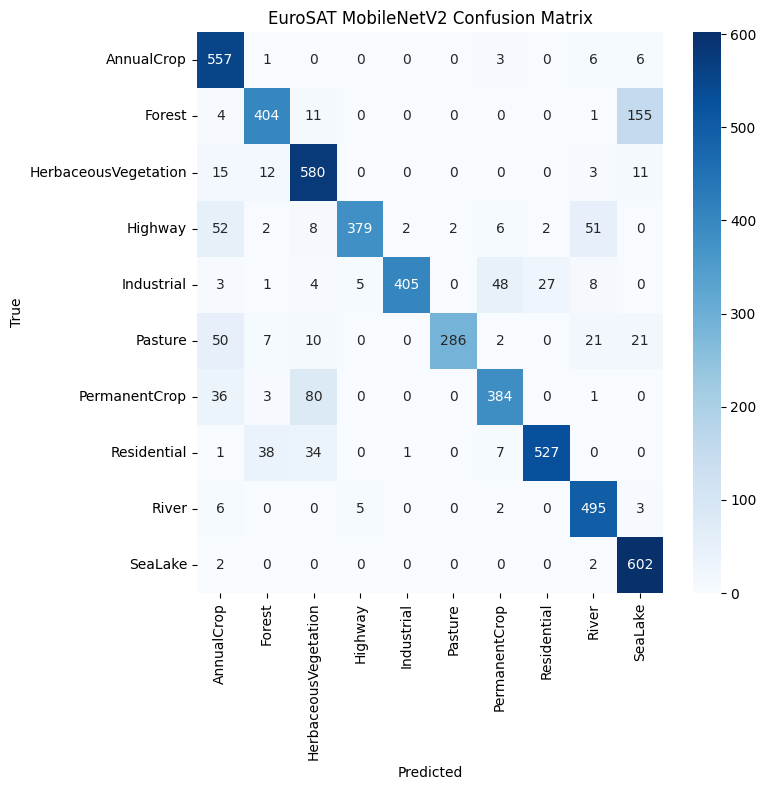

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 10})
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EuroSAT MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.show() # Display the plot directly

In [20]:
# 16. Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure FIGS_DIR is defined, which it is from earlier cells.

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 10})
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EuroSAT MobileNetV2 Confusion Matrix")

fig_path = os.path.join(FIGS_DIR, "eurosat_mobilenetv2_confusion_matrix.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.close()
print("Saved confusion matrix figure to:", fig_path)

Saved confusion matrix figure to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/figs/eurosat_mobilenetv2_confusion_matrix.png


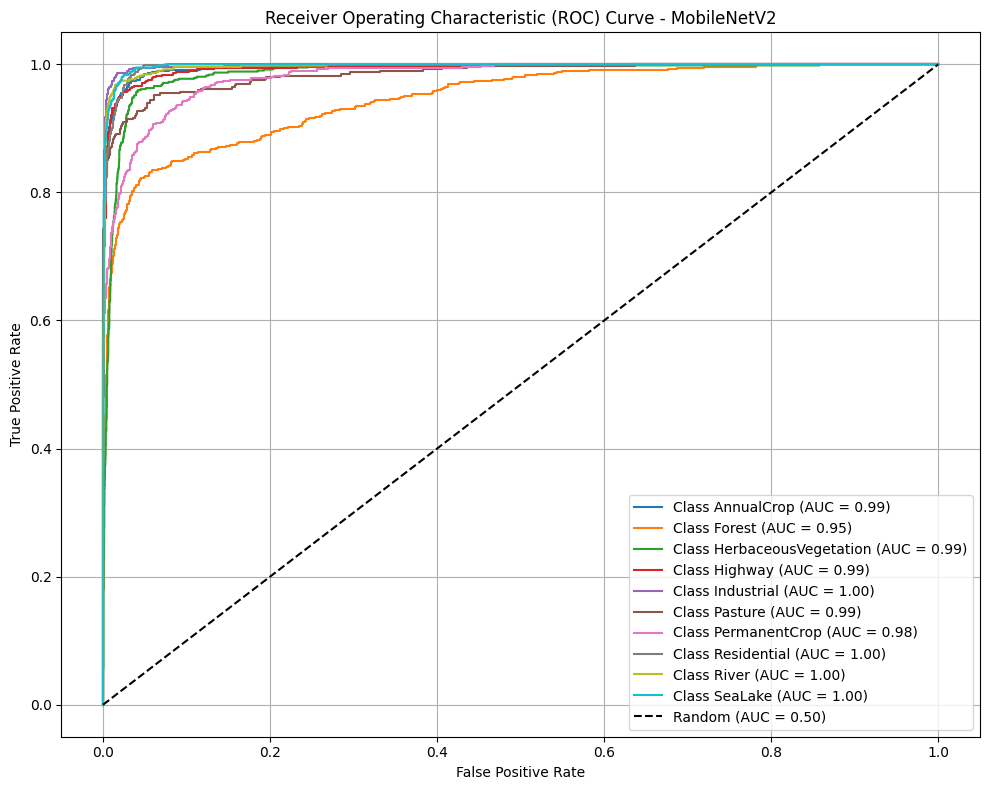

In [21]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Convert y_true to one-hot encoding for ROC curve calculation
y_true_one_hot = to_categorical(y_true, num_classes=num_classes)

plt.figure(figsize=(10, 8))

# Calculate ROC curve and AUC for each class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_score[:, i]) # Use y_score instead of preds
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - MobileNetV2')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

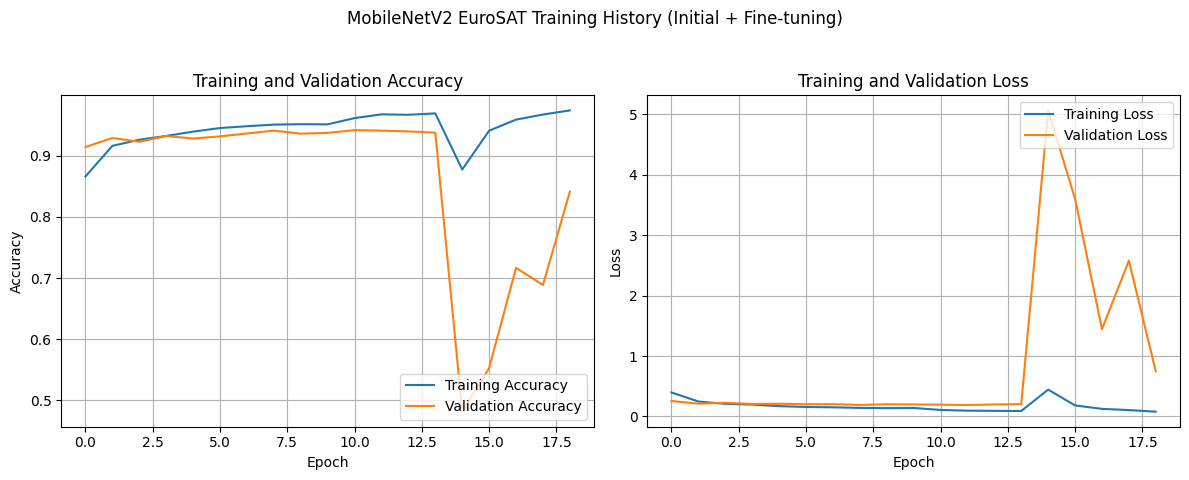

In [22]:
import matplotlib.pyplot as plt

def plot_history(history, history_ft=None, title='Model Training History'):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    if not acc:
        print("Warning: Training accuracy data not found in history. Cannot plot.")
        return

    epochs_range = range(len(acc))

    if history_ft:
        ft_acc = history_ft.history.get('accuracy', [])
        ft_val_acc = history_ft.history.get('val_accuracy', [])
        ft_loss = history_ft.history.get('loss', [])
        ft_val_loss = history_ft.history.get('val_loss', [])

        acc = acc + ft_acc
        val_acc = val_acc + ft_val_acc
        loss = loss + ft_loss
        val_loss = val_loss + ft_val_loss
        epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    if val_acc:
        plt.plot(epochs_range[:len(val_acc)], val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    if val_loss:
        plt.plot(epochs_range[:len(val_loss)], val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Call the function to plot the history
plot_history(history, history_ft, title='MobileNetV2 EuroSAT Training History (Initial + Fine-tuning)')

In [23]:
print("\n--- Overall Model Metrics ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision (Macro Avg): {report['macro avg']['precision']:.4f}")
print(f"Recall (Macro Avg): {report['macro avg']['recall']:.4f}")
print(f"F1-score (Macro Avg): {report['macro avg']['f1-score']:.4f}")


--- Overall Model Metrics ---
Accuracy: 0.8550
Precision (Macro Avg): 0.8782
Recall (Macro Avg): 0.8480
F1-score (Macro Avg): 0.8535
